In [2]:
import pandas as pd
import numpy as np

In [3]:
import pandas as pd
pd.options.mode.chained_assignment = None  # Disable the warning


In [4]:
df=pd.read_csv("D:\\DATA\\phone search.csv")

Step 1:I looked up for duplicated rows in asin and delete them.


In [5]:

duplicates = df[df.duplicated(subset=['asin'], keep=False)]
print(duplicates)

           asin                                      product_title  \
0    B0BQ118F2T  Moto G Play 2023 3-Day Battery Unlocked Made f...   
1    B0CV2W1TKZ  Samsung Galaxy A15 (SM-155M/DSN), 128GB 6GB RA...   
2    B09SM24S8C  Samsung Galaxy A03s Cell Phone, AT&amp;T GSM U...   
3    B0CHH1N9VY  TracFone | Motorola Moto g Pure | Locked | 32G...   
4    B09T3MQSVP  Samsung Galaxy A13 5G Cell Phone, AT&amp;T GSM...   
5    B0BZG14KFJ  Panasonic Cordless Phone with Answering Machin...   
6    B0C2SWQBMB  Motorola Moto G 5G | 2023 | Unlocked | Made fo...   
7    B0CTD47P22  Samsung Galaxy A15 A155M 128GB Dual-SIM GSM Un...   
8    B0CSB14R7J  Samsung Galaxy A15 A155M 128GB Dual-SIM GSM Un...   
9    B0CHK6LWKZ  TracFone | Samsung Galaxy A03s | Locked | 32GB...   
10   B0C5BMB1WB  Motorola One Ace | 2021 | 2-Day Battery | Unlo...   
11   B0CRVWPWKP  Samsung Galaxy A25 5G A256E 128GB Dual-SIM GSM...   
12   B0CN1QSH8Q  SAMSUNG Galaxy A15 5G A Series Cell Phone, 128...   
13   B0C22BRGLG  One

In [6]:
df.sample

<bound method NDFrame.sample of            asin                                      product_title  \
0    B0BQ118F2T  Moto G Play 2023 3-Day Battery Unlocked Made f...   
1    B0CV2W1TKZ  Samsung Galaxy A15 (SM-155M/DSN), 128GB 6GB RA...   
2    B09SM24S8C  Samsung Galaxy A03s Cell Phone, AT&amp;T GSM U...   
3    B0CHH1N9VY  TracFone | Motorola Moto g Pure | Locked | 32G...   
4    B09T3MQSVP  Samsung Galaxy A13 5G Cell Phone, AT&amp;T GSM...   
..          ...                                                ...   
335  B0CZ3YPSRX  Gimbal Stabilizer for Smartphone, 3-Axis Phone...   
336  B0CHB24KQJ  [True Military-Grade] Car Phone Holder【2024 St...   
337  B01LXOPZ4W  Wall Mount Cell Phone Charging Shelf | Multi-D...   
338  B0CXPJK7F7  Sensyne 92&quot; Cell Phone Tripod, Selfie Sti...   
339  B0CQ237PFS  Portable Charger 33800mAh USB C Power Bank wit...   

    product_price product_original_price currency  product_star_rating  \
0         $99.00                $169.99       USD    

In [7]:
df = df.drop_duplicates(subset=['asin'])

In [8]:

duplicates = df[df.duplicated(subset=['asin'], keep=False)]
print(duplicates)

Empty DataFrame
Columns: [asin, product_title, product_price, product_original_price, currency, product_star_rating, product_num_ratings, product_num_offers, product_minimum_offer_price, is_best_seller, is_amazon_choice, is_prime, product_availability, climate_pledge_friendly, sales_volume, delivery, has_variations, unit_price, unit_count, coupon_text]
Index: []


STEP 2: changed the text into numbers and removed wrong data and filled the missing values by the median.

In [9]:
df['sales_volume'].sample

<bound method NDFrame.sample of 0       4K+ bought in past month
1       1K+ bought in past month
2       2K+ bought in past month
3      500+ bought in past month
4      500+ bought in past month
                 ...            
335                          NaN
336     50+ bought in past month
337                          NaN
338    300+ bought in past month
339     3K+ bought in past month
Name: sales_volume, Length: 315, dtype: object>

In [10]:
df[['sales_volume', 'col2']] = df['sales_volume'].str.split('+', expand=True)
df['sales_volume']=df['sales_volume'].str.replace('K','000',regex=True)
df['sales_volume'] = df['sales_volume'].str.extract(r'(\d+)', expand=False)

In [11]:
df.sample

<bound method NDFrame.sample of            asin                                      product_title  \
0    B0BQ118F2T  Moto G Play 2023 3-Day Battery Unlocked Made f...   
1    B0CV2W1TKZ  Samsung Galaxy A15 (SM-155M/DSN), 128GB 6GB RA...   
2    B09SM24S8C  Samsung Galaxy A03s Cell Phone, AT&amp;T GSM U...   
3    B0CHH1N9VY  TracFone | Motorola Moto g Pure | Locked | 32G...   
4    B09T3MQSVP  Samsung Galaxy A13 5G Cell Phone, AT&amp;T GSM...   
..          ...                                                ...   
335  B0CZ3YPSRX  Gimbal Stabilizer for Smartphone, 3-Axis Phone...   
336  B0CHB24KQJ  [True Military-Grade] Car Phone Holder【2024 St...   
337  B01LXOPZ4W  Wall Mount Cell Phone Charging Shelf | Multi-D...   
338  B0CXPJK7F7  Sensyne 92&quot; Cell Phone Tripod, Selfie Sti...   
339  B0CQ237PFS  Portable Charger 33800mAh USB C Power Bank wit...   

    product_price product_original_price currency  product_star_rating  \
0         $99.00                $169.99       USD    

In [12]:
df['sales_volume']=pd.to_numeric(df['sales_volume'], errors='coerce')
df['product_star_rating']=pd.to_numeric(df['product_star_rating'], errors='coerce')
df['product_num_ratings']=pd.to_numeric(df['product_num_ratings'], errors='coerce')
df['product_num_offers']=pd.to_numeric(df['product_num_offers'], errors='coerce')


In [13]:
df.sample

<bound method NDFrame.sample of            asin                                      product_title  \
0    B0BQ118F2T  Moto G Play 2023 3-Day Battery Unlocked Made f...   
1    B0CV2W1TKZ  Samsung Galaxy A15 (SM-155M/DSN), 128GB 6GB RA...   
2    B09SM24S8C  Samsung Galaxy A03s Cell Phone, AT&amp;T GSM U...   
3    B0CHH1N9VY  TracFone | Motorola Moto g Pure | Locked | 32G...   
4    B09T3MQSVP  Samsung Galaxy A13 5G Cell Phone, AT&amp;T GSM...   
..          ...                                                ...   
335  B0CZ3YPSRX  Gimbal Stabilizer for Smartphone, 3-Axis Phone...   
336  B0CHB24KQJ  [True Military-Grade] Car Phone Holder【2024 St...   
337  B01LXOPZ4W  Wall Mount Cell Phone Charging Shelf | Multi-D...   
338  B0CXPJK7F7  Sensyne 92&quot; Cell Phone Tripod, Selfie Sti...   
339  B0CQ237PFS  Portable Charger 33800mAh USB C Power Bank wit...   

    product_price product_original_price currency  product_star_rating  \
0         $99.00                $169.99       USD    

In [14]:
df['sales_volume'].sample

<bound method NDFrame.sample of 0      4000.0
1      1000.0
2      2000.0
3       500.0
4       500.0
        ...  
335       NaN
336      50.0
337       NaN
338     300.0
339    3000.0
Name: sales_volume, Length: 315, dtype: float64>

<Axes: >

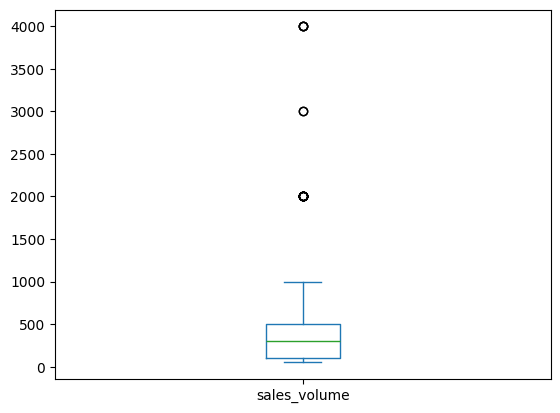

In [15]:
df['sales_volume'].plot(kind='box')

In [16]:
df['sales_volume'].describe()

count     270.000000
mean      484.444444
std       663.716210
min        50.000000
25%       100.000000
50%       300.000000
75%       500.000000
max      4000.000000
Name: sales_volume, dtype: float64

In [17]:
df['sales_volume'].skew()

np.float64(3.1734982333631665)

In [18]:
df['sales_volume'].fillna(df['sales_volume'].median(),inplace=True)

Step 3: changed the type of data in columns (sales_volume, Product_price, Product_original_price, product_minimum_offer_price,product_star_rating,product_num_offers,product_num_ratings ):

In [19]:
df['product_price'] = df['product_price'].replace(r'[\$,]', '', regex=True).astype(float)
df['product_minimum_offer_price'] =df['product_minimum_offer_price'].replace(r'[\$,]','',regex=True).astype(float)
df['product_original_price']=df['product_original_price'].replace(r'[\$,]','',regex=True).astype(float)

In [20]:
df['sales_volume']=pd.to_numeric(df['sales_volume'], errors='coerce').astype('Int64')
df['product_star_rating']=pd.to_numeric(df['product_star_rating'],errors='coerce')
df['product_num_ratings']=pd.to_numeric(df['product_num_ratings'],errors='coerce').astype('Int64')
df['product_num_offers']=pd.to_numeric(df['product_num_offers'],errors='coerce').astype('Int64')
df['product_price']=pd.to_numeric(df['product_price'])
df['product_original_price']=pd.to_numeric(df['product_original_price'])
df['product_minimum_offer_price']=pd.to_numeric(df['product_minimum_offer_price'])



In [21]:
df.dtypes

asin                            object
product_title                   object
product_price                  float64
product_original_price         float64
currency                        object
product_star_rating            float64
product_num_ratings              Int64
product_num_offers               Int64
product_minimum_offer_price    float64
is_best_seller                    bool
is_amazon_choice                  bool
is_prime                          bool
product_availability            object
climate_pledge_friendly           bool
sales_volume                     Int64
delivery                        object
has_variations                    bool
unit_price                      object
unit_count                     float64
coupon_text                     object
col2                            object
dtype: object

STEP 4: dropped unnecessary columns.
 

In [22]:
df.drop(['unit_price','unit_count','coupon_text','col2'],axis=1,inplace=True)

STEP5: fill the product price and the minimum price offer with median.


In [23]:
df.isnull().any()

asin                           False
product_title                  False
product_price                   True
product_original_price          True
currency                        True
product_star_rating             True
product_num_ratings            False
product_num_offers             False
product_minimum_offer_price     True
is_best_seller                 False
is_amazon_choice               False
is_prime                       False
product_availability            True
climate_pledge_friendly        False
sales_volume                   False
delivery                        True
has_variations                 False
dtype: bool

<Axes: >

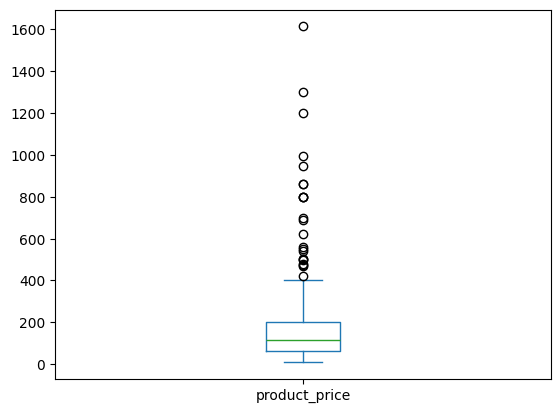

In [24]:
df['product_price'].plot(kind='box')

In [25]:
df['product_price'].describe()



count     311.000000
mean      171.830386
std       202.160972
min         7.990000
25%        59.990000
50%       113.870000
75%       199.990000
max      1614.990000
Name: product_price, dtype: float64

In [26]:
df['product_price'].skew()


np.float64(3.363193782105881)

In [27]:
df['product_price'].fillna(df['product_price'].median(),inplace=True)

In [28]:
df['product_price'].isna().sum()


np.int64(0)

In [29]:
df['product_minimum_offer_price'].describe()

count     311.000000
mean      146.139260
std       190.494996
min         7.990000
25%        43.940000
50%        82.170000
75%       164.970000
max      1583.650000
Name: product_minimum_offer_price, dtype: float64

In [30]:
df['product_minimum_offer_price'].skew()

np.float64(3.5988765292113545)

In [31]:
df['product_minimum_offer_price'].fillna(df['product_minimum_offer_price'].median(),inplace=True)

C:\Users\alaa_\AppData\Local\Temp\ipykernel_17172\420230828.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['product_minimum_offer_price'].fillna(df['product_minimum_offer_price'].median(),inplace=True)


In [32]:
df['product_star_rating'].isna().sum()

np.int64(3)

In [33]:
df['product_star_rating'].skew()

np.float64(-1.4111119531343164)

In [34]:
df['product_num_offers'].skew()

np.float64(2.803013713072802)

In [35]:

df['product_num_ratings'].skew()

np.float64(5.132003945603929)

In [36]:
df['product_star_rating'].fillna(df['product_star_rating'].median(),inplace=True)
df['product_num_offers'].fillna(df['product_num_offers'].median(),inplace=True)
df['product_num_ratings'].fillna(df['product_num_ratings'].median(),inplace=True)

C:\Users\alaa_\AppData\Local\Temp\ipykernel_17172\3766104411.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['product_star_rating'].fillna(df['product_star_rating'].median(),inplace=True)
C:\Users\alaa_\AppData\Local\Temp\ipykernel_17172\3766104411.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values a

STEP 6: fill the the original product price with the product price



In [82]:
df['product_original_price']=df['product_original_price'].fillna(df['product_price'])

In [83]:
df.isnull().any()

asin                           False
product_title                  False
product_price                  False
product_original_price         False
currency                        True
product_star_rating            False
product_num_ratings            False
product_num_offers             False
product_minimum_offer_price    False
is_best_seller                 False
is_amazon_choice               False
is_prime                       False
product_availability            True
climate_pledge_friendly        False
sales_volume                   False
delivery                        True
has_variations                 False
dtype: bool

STEP7:fill the remaining columns:


In [84]:
df['currency']=df['currency'].fillna('USD')

In [85]:
df['product_availability']=df['product_availability'].fillna('Available')

In [86]:
df['delivery'].isna().sum()

np.int64(3)

In [87]:
df['delivery']=df['delivery'].fillna('FREE delivery')

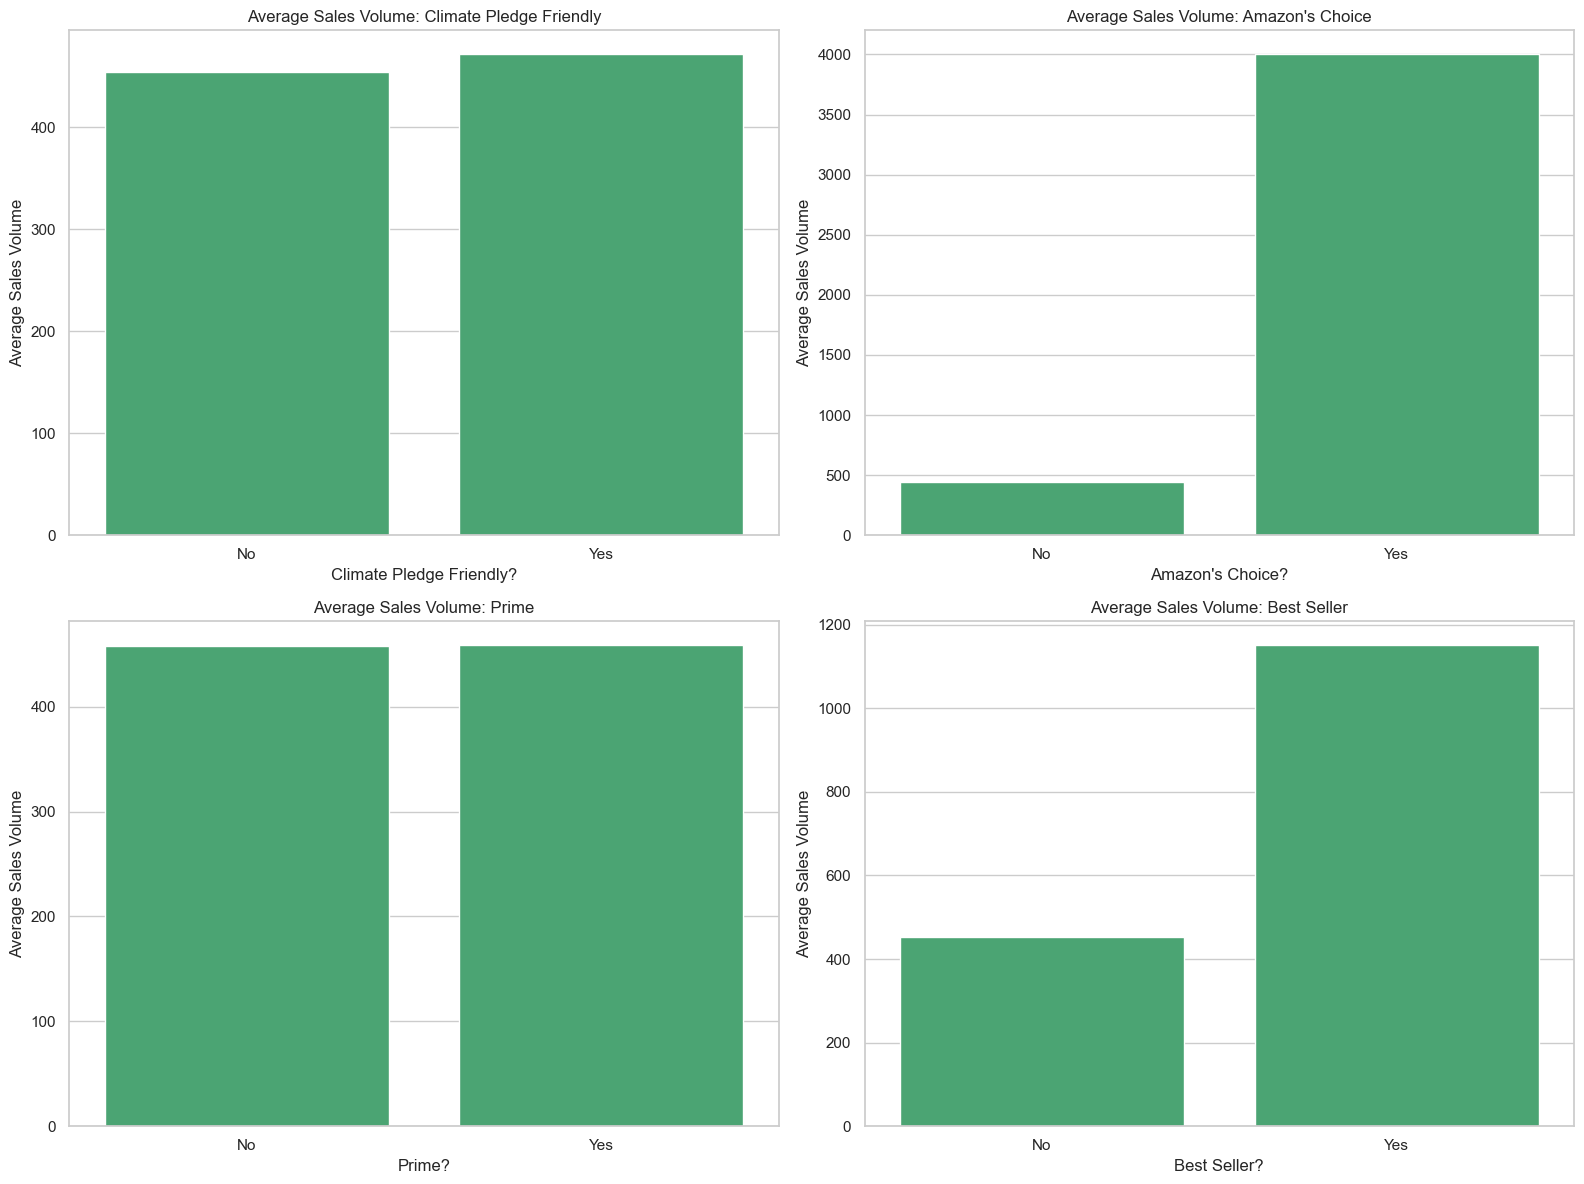

In [91]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

fig, axs = plt.subplots(2, 2, figsize=(16, 12))
badges = ['climate_pledge_friendly', 'is_amazon_choice', 'is_prime', 'is_best_seller']
titles = ["Climate Pledge Friendly", "Amazon's Choice", "Prime", "Best Seller"]

for ax, badge, title in zip(axs.flatten(), badges, titles):
    # Group by True/False and get average sales_volume
    grouped = df.groupby(badge)['sales_volume'].mean().reset_index()

    # Optional: convert True/False to Yes/No for labels
    grouped[badge] = grouped[badge].map({False: 'No', True: 'Yes'})

    sns.barplot(x=badge, y='sales_volume', data=grouped, ax=ax, color='mediumseagreen')
    ax.set_title(f"Average Sales Volume: {title}")
    ax.set_xlabel(f"{title}?")
    ax.set_ylabel("Average Sales Volume")

plt.tight_layout()
plt.show()


In [ ]:
df.to_csv("C:\\Users\\alaa_\\Downloads\\df.csv", index=False)
